# Use-case: Partial plots to study interactions on residuals

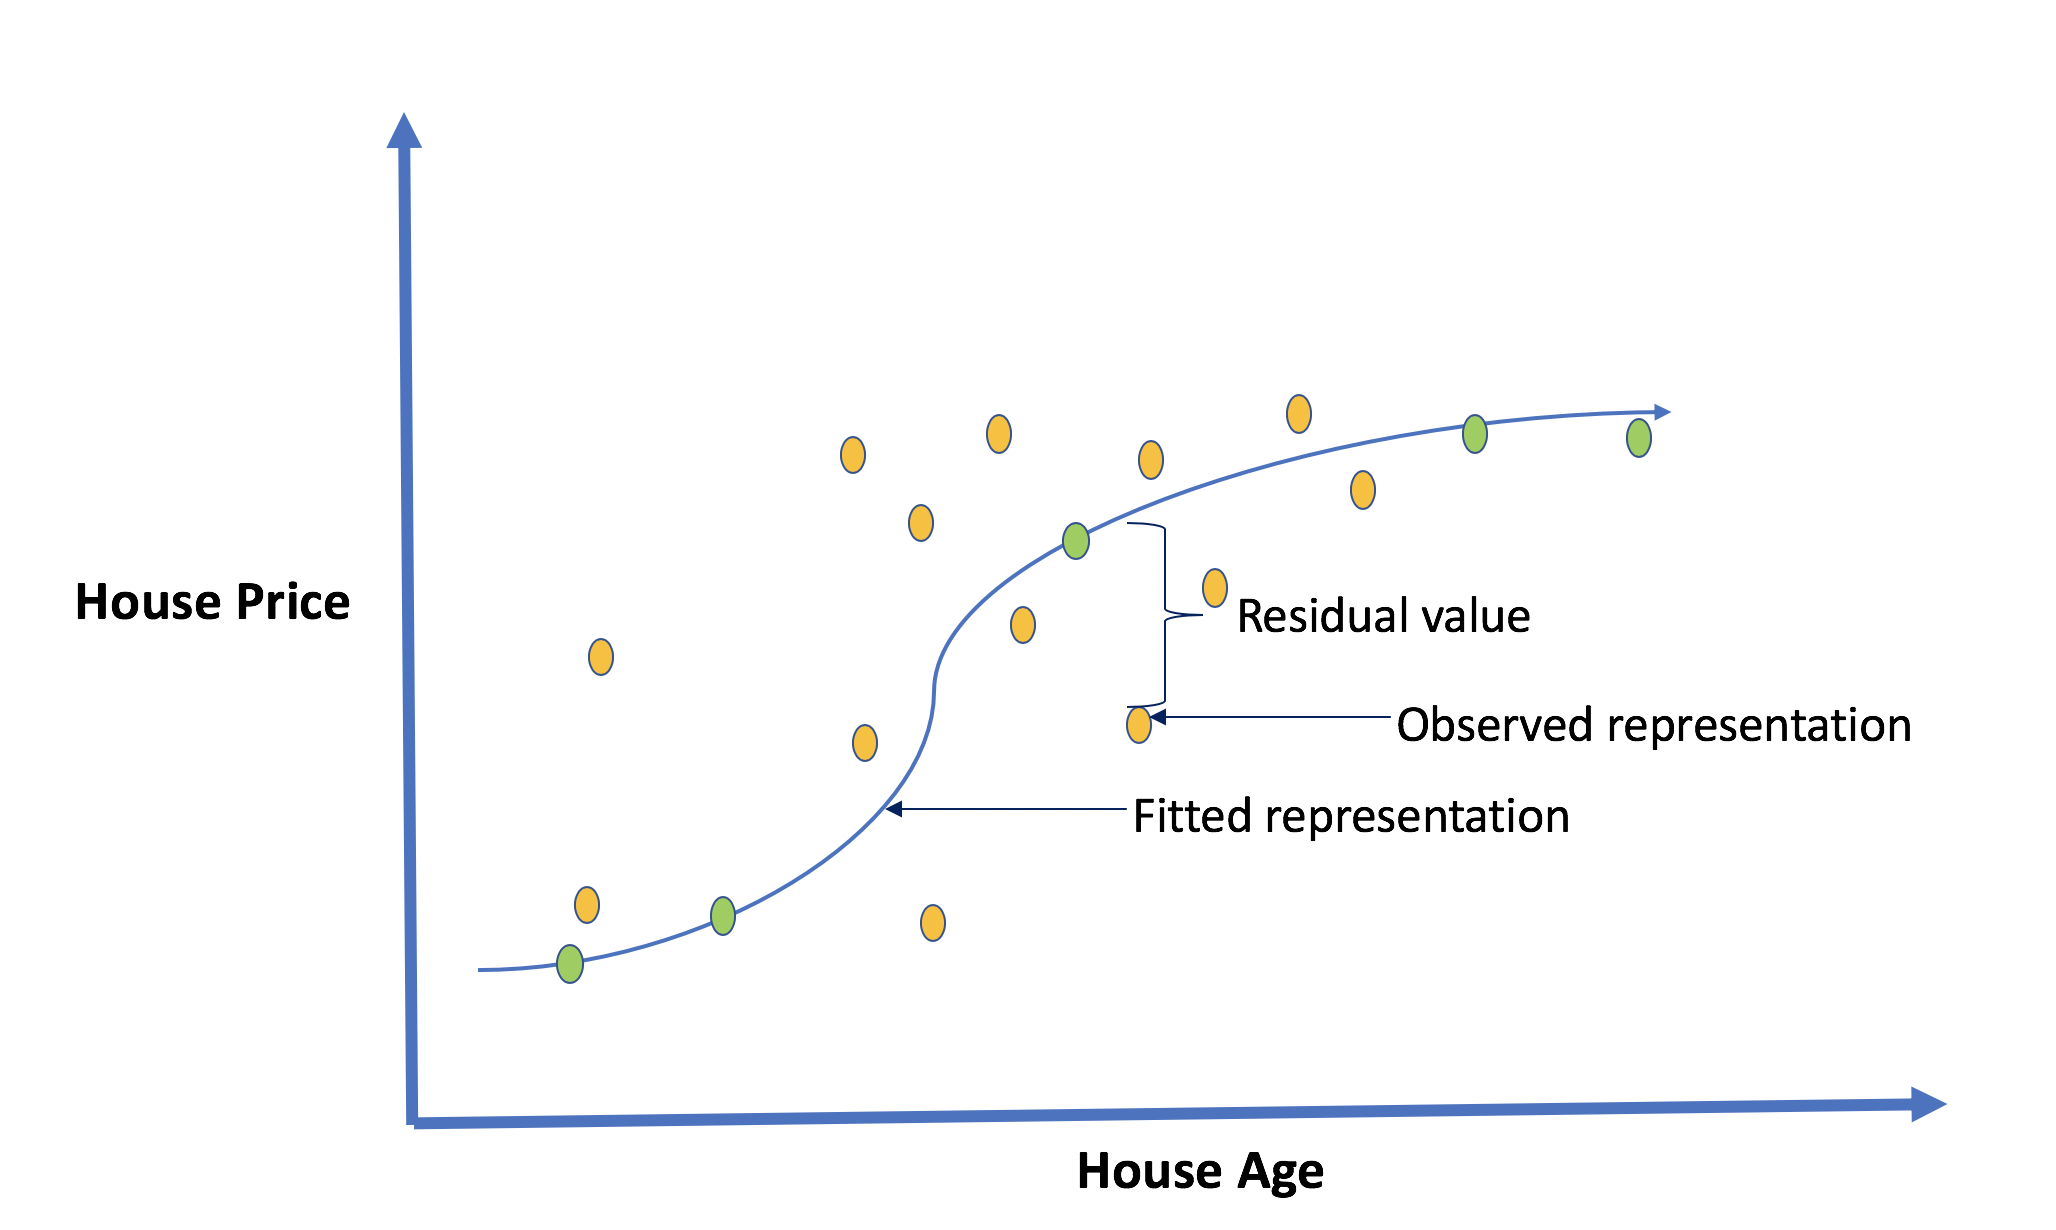

In [196]:
from IPython.display import Image
Image("img/residual_vs_observed.png")

### 1. Load the dataset

In [197]:
# For this use-case we will be using well studied Boston dataset(Learning to predict House prices)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from timeit import default_timer as timer

from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble.partial_dependence import plot_partial_dependence
from sklearn.ensemble.partial_dependence import partial_dependence
from sklearn.datasets import load_boston

import lightgbm as lgb

from mli.explanation.h_statistic import HStatistic
from mli.explanation.pd import PD

# Load the dataset
botons_housing = load_boston()
print(botons_housing.DESCR)

# split 80/20 train-test (Feel free to change the split size to study the shift in prediction and accuracy)
X_train, X_test, y_train, y_test = train_test_split(botons_housing.data,
                                                        botons_housing.target,
                                                        test_size=0.2,
                                                        random_state=1)

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

### 2. Basic data formatting and conversion

In [198]:
feature_names = list(botons_housing['feature_names'])
print(f"Feature Names: {feature_names}")

Feature Names: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [199]:
# Since, the loaded data is in the `sklearn.utils.Bunch` format we have to manually convert it to pandas dataframe
# DAI has the ability to automatically summarize the data distribuion to get a comprehensive view of the data.

data_df_train = pd.DataFrame(data=X_train, columns=feature_names)

data_df_test = pd.DataFrame(data=X_test, columns=feature_names)
print(data_df_train.head(5))

print("\n\n")
print(f"Shape of the training data {data_df_train.shape}")
print(f"Shape of the test data {data_df_test.shape}")

       CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS   RAD    TAX  \
0   0.14150   0.0   6.91   0.0  0.448  6.169   6.6  5.7209   3.0  233.0   
1   0.15445  25.0   5.13   0.0  0.453  6.145  29.2  7.8148   8.0  284.0   
2  16.81180   0.0  18.10   0.0  0.700  5.277  98.1  1.4261  24.0  666.0   
3   0.05646   0.0  12.83   0.0  0.437  6.232  53.7  5.0141   5.0  398.0   
4   8.79212   0.0  18.10   0.0  0.584  5.565  70.6  2.0635  24.0  666.0   

   PTRATIO       B  LSTAT  
0     17.9  383.37   5.81  
1     19.7  390.68   6.86  
2     20.2  396.90  30.81  
3     18.7  386.40  12.34  
4     20.2    3.65  17.16  



Shape of the training data (404, 13)
Shape of the test data (102, 13)


### 3. Modeling
We will be building 2 non-DAI models initially and compare the performance using the MLI python client. Following that we will be using DAI to enable automated feature engineering and modeling.

In [ ]:
# First just using bare bone lightgbm
lgb_train = lgb.Dataset(X_train, y_train, free_raw_data=False)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train, free_raw_data=False)

# specify your configurations as a dict.
# **The below mentioned config is not from a specific recipe and is completely experimental.
params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'rmse', # one can also try regression_l2
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0
}

print('Starting training...')
# feature_name and categorical_feature
gbm1 = lgb.train(params,
                lgb_train,
                num_boost_round=40,
                valid_sets=lgb_train,  # eval training data
                feature_name=feature_names)

In [ ]:
# specify your configurations as a dict
params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'rmse', # one can also try regression_l2
    'num_leaves': 50,
    'learning_rate': 0.08,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0
}

gbm2 = lgb.train(params,
                lgb_train,
                num_boost_round=50,
                valid_sets=lgb_train,  # eval training data
                feature_name=feature_names)

### 4. Quick Evaluation
We will be using R^2 and adjusted R^2 for evaluating the models

In [ ]:
def compute_metrics(model_instance, input_X , input_y):
    # simply computing the response on dependent data
    y_hat = model_instance.predict(input_X)

    # Compute different metrics
    sum_sqaure_error = np.sum(np.square(input_y - y_hat))
    sum_of_square_total = np.sum(np.square(input_y - np.mean(input_y)))

    # Computing R^2
    r_2 = 1 - (float(sum_sqaure_error))/sum_of_square_total

    # Computing adjusted R^2
    adj_r_2 = 1 - ((1-r_2)*(len(input_y)-1))/(len(input_y)- input_X.shape[1] - 1)
    return ({"R2":r_2, "Adjusted R2":adj_r_2})

In [203]:
print("Train set diagnostic ...")
print(f"Model 1: {compute_metrics(gbm1, X_train, y_train)}")
print(f"Model 2: {compute_metrics(gbm2, X_train, y_train)}")

print("\n\n\n")

print("Test set diagnostic ...")
print(f"Model 1: {compute_metrics(gbm1, X_test, y_test)}")
print(f"Model 2: {compute_metrics(gbm2, X_test, y_test)}")

Train set diagnostic ...
Model 1: {'R2': 0.8549365093022722, 'Adjusted R2': 0.8501010596123479}
Model 2: {'R2': 0.9155397033163164, 'Adjusted R2': 0.912724360093527}




Test set diagnostic ...
Model 1: {'R2': 0.8233007508496542, 'Adjusted R2': 0.7971974526797168}
Model 2: {'R2': 0.8771231033266603, 'Adjusted R2': 0.858970834499917}


#### Observation:
Both the models are doing decently ok. Slight different in R^2 and adjusted R^2 is noticed. 
That might need further exploration.

### 5. Interpreting the results

### 5.1 Residual plots:
The residual of a fitted model is difference between the observed value and estimated(_predicted_) value. When applied to `regression` use-case it could also be referred as `statistical error`. It's a quick graphically interpretable technique to understand the variance in error distribution.

#### Definition for residual:
error = y_true - y_hat

#### Take away:
- Ideally, the difference between observed value and estimated should be stochastic(random and unpredictable) for a well fitted model.
- If some pattern is observed in the residuals, it indicates that the fitted model failed to capture deterministic predictive pattern in the data(_indicates error in the predictive power of the model_)

In [ ]:
# A simple plotting exercise
import matplotlib.pyplot as plt
plt.style.use('ggplot')

y_hat1 = gbm1.predict(X_train)
y_hat2 = gbm2.predict(X_train)
residuals1 = y_train - y_hat1
residuals2 = y_train - y_hat2

In [ ]:
# Interactive plots
import plotly
from plotly import tools
import plotly.plotly as py
import plotly.graph_objs as go

plotly.offline.init_notebook_mode(connected=True)

model1 = go.Scatter(
    x=y_hat1,
    y=residuals1,
    mode="markers",
    marker = dict(color = 'blue'),
    name='Model 1'
)
model2 = go.Scatter(
    x=y_hat2,
    y=residuals2,
    mode="markers",
    marker = dict(color = 'orange'),
    name='Model 2'
)

data = [model1, model2]
layout = go.Layout(
    title='Residuals vs Predicted',
    xaxis=dict(
        title='Predicted(based on fitted model)',
        titlefont=dict(
            family='Courier New, monospace',
            size=18,
            color='#7f7f7f'
        )
    ),
    yaxis=dict(
        title='Residuals',
        titlefont=dict(
            family='Courier New, monospace',
            size=18,
            color='#7f7f7f'
        )
    )
)

fig = go.Figure(data, layout=layout)
plotly.offline.iplot(fig, filename='residual comparison')

#### Observation:
In the above example, the model seems to be decently fine(**Train:** 0.91; **Test:** 0.88), as there is no systematic "highs" or "lows". 
For most part the values seems to be centered around `zero` throughout the range of fitted values.

#### Reference: 
- Tsai, Chih-Ling, Cai Zongwu and WuThe Xizhi (1998). Examination of residual plots (http://www3.stat.sinica.edu.tw/statistica/oldpdf/A8n29.pdf)

### 5.2 Enabling Partial Plot for further exploration

#### 5.2.1: Partial before any filtering on the residuals

In [151]:
# Re-creating the frame again for the full dataset
x_df = pd.DataFrame(data=X_train, columns=feature_names)

pdp1 = PD("Boston Housing partial residual")
feature_name = ['INDUS']


def predict_non_dai(X):
    return pd.DataFrame(gbm2.predict(X))[0]


start = timer()
# no filtering
pdp1.explain(features=feature_name, X=x_df, Y=pd.DataFrame(y_train), predict_method=predict_non_dai)
end = timer()
print(end - start)

0.10730747086927295


#### 5.2.2: Partial plot post filtering the residuals

In [ ]:
# Filter datapoints from the training sample based on distance from the center.
# For e.g. Query for all the points which have `-ve` residuals.
# One can change the filter value to suit their needs
points_less_than_0_index = np.argwhere(residuals1 < -5)

print(f"Residual shape before filtering: {len(residuals1)} rows")
print(f"Residual shape post filtering: {len(points_less_than_0_index)} rows")

# Filter out the training points
# flatten the array(list)
indexes = [i[0] for i in points_less_than_0_index]
x_train_filter = X_train[indexes]
y_train_filter = y_train[indexes]

Residual shape before filtering: 404 rows
Residual shape post filtering: 10 rows


In [153]:
# With filtering ...
from mli.explanation.pd import PD

x_df = pd.DataFrame(data=x_train_filter, columns=feature_names)

pdp2 = PD("Boston Housing partial residual")
feature_name = ['INDUS']


def predict_non_dai(X):
    return pd.DataFrame(gbm2.predict(X))[0]


start = timer()
pdp2.explain(features=feature_name, X=x_df, Y=pd.DataFrame(y_train_filter), predict_method=predict_non_dai)
end = timer()
print(end - start)

0.09684792906045914


In [ ]:
def simple_plot(X1, X2=None, feature_name=feature_name):
    model1 = go.Scatter(
    x=X1[feature_name[0]]['p_0'].columns.values,
    y=X1[feature_name[0]]['p_0'].T['mean'].values,
    marker = dict(color = 'blue'),
    name='Residual On full dataset')

    model2 = go.Scatter(
    x=X2[feature_name[0]]['p_0'].columns.values,
    y=X2[feature_name[0]]['p_0'].T['mean'].values,
    marker = dict(color = 'orange'),
    name='Filtered residuals')

    data = [model1, model2]
    layout = go.Layout(
    title='One-way interaction(PDP)',
    xaxis=dict(
        title=f"{feature_name[0]}(proportion of non-retail business acres per town)",
        titlefont=dict(
            family='Courier New, monospace',
            size=18,
            color='#7f7f7f'
        )
    ),
    yaxis=dict(
        title='Housing Price',
        titlefont=dict(
            family='Courier New, monospace',
            size=18,
            color='#7f7f7f'
        )))

    fig = go.Figure(data, layout=layout)
    plotly.offline.iplot(fig, filename='oneway_interaction')

#### Visualizing PDP on the full dataset(partial interaction is optimized on residuals) vs filtered residuals

In [167]:
# With interactive plot on can zoom in to get more insight.
simple_plot(pdp1.explanations(), pdp2.explanations())

### 6. Let's try with DAI model

### 6.1. Connect to DAI instance

In [158]:
# Using the latest release DAI-1.5.2
# Step 1: Upload the data to DAI engine
import requests
import math
import os
import pandas as pd
from h2oai_client import Client, ModelParameters, InterpretParameters

In [ ]:
import os

# remember to change the IP name to relevant DAI instance.
ip = 'prerelease.h2o.ai'
username = 'h2oai'
# use environment variables or secure credential stores
password = os.getenv('H2O_PASSWORD', 'h2oai')  # default for local testing only

h2oai = Client(address = 'http://' + ip, username=username, password=password)

# info about the DAI Client:
print(h2oai.address)

### 6.2. Upload dataset to Driverless AI

In [160]:
feature_list = feature_names + ['target']
print(feature_list)


# train
data_df_train = pd.DataFrame(data=np.c_[X_train, y_train],
                         columns=feature_list)
print(data_df_train.head(2))

# test
data_df_test = pd.DataFrame(data=np.c_[X_test, y_test],
                         columns=feature_list)
print(data_df_test.head(2))


# persist the dataframes
data_df_train.to_csv("boston_housing_data_train.csv", index=False)
data_df_test.to_csv("boston_housing_data_test.csv", index=False)

current_directory = os.getcwd()

train_path_dai = f"{current_directory}/boston_housing_data_train.csv"
test_path_dai = f"{current_directory}/boston_housing_data_test.csv"

# Upload datasets to DAI instance for running an experiment.
train = h2oai.upload_dataset_sync(train_path_dai)
test = h2oai.upload_dataset_sync(test_path_dai)

['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'target']
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.14150   0.0   6.91   0.0  0.448  6.169   6.6  5.7209  3.0  233.0   
1  0.15445  25.0   5.13   0.0  0.453  6.145  29.2  7.8148  8.0  284.0   

   PTRATIO       B  LSTAT  target  
0     17.9  383.37   5.81    25.3  
1     19.7  390.68   6.86    23.3  
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.04932  33.0   2.18   0.0  0.472  6.849  70.3  3.1827  7.0  222.0   
1  0.02543  55.0   3.78   0.0  0.484  6.696  56.4  5.7321  5.0  370.0   

   PTRATIO      B  LSTAT  target  
0     18.4  396.9   7.53    28.2  
1     17.6  396.9   7.18    23.9  
/home/ubuntu/h2o/mli-2


### 6.3. Set up parameters for Driverless AI experiment

In [ ]:
# Set the parameters you want to pass to DAI
dataset_key=train.key # Dataset to use for DAI
validset_key='' # Validation set to use for DAI (Note, we are not using one for this experiment)
testset_key=test.key # Test set to use for DAI
target="target" # Target column for DAI
# dropped_cols=["sample_weight"] #List of columns to drop. In this case we are dropping 'sample_weight'
weight_col=None # The column that indicates the per row observation weights.
                # If None, each row will have an observation weight of 1
fold_col=None # The column that indicates the fold. If None, the folds will be determined by DAI

is_time_series=False # Whether or not the experiment is a time series problem
is_classification=False # Inform DAI if the problem type is a classification (binomial/multinomial)
                    # or not (regression)

enable_gpus=True # Whether or not to enable GPUs
seed=42 # Use seed for reproducibility
scorer_str='R2' # Set evaluation metric. In this case we are interested in optimizing R-squared
accuracy=1 # Accuracy setting for experiment (One of the 3 knobs you see in the DAI UI)
time=1 # Time setting for experiment (One of the 3 knobs you see in the DAI UI)
interpretability=2 # Interpretability setting for experiment (One of the 3 knobs you see in the DAI UI)
config_overrides=None # Extra parameters that can be passed in TOML format

In [ ]:
experiment = h2oai.start_experiment_sync(
    #Datasets
    dataset_key=dataset_key,
    validset_key = validset_key,
    testset_key=testset_key,

    #Columns
    target_col=target,

    #Parameters
    is_classification=is_classification,
    enable_gpus=enable_gpus,
    seed=seed,
    accuracy=accuracy, # DAI suggested for accuracy
    time=time, # DAI suggested for time
    interpretability=interpretability, # DAI suggested for interpretability
    scorer=scorer_str,
    # Extra parameters that can be passed in TOML format
    config_overrides=None
)

In [163]:
print(f"Name of the experiment: {experiment.description}")

# Download Summary
import subprocess
summary_path = h2oai.download(src_path=experiment.summary_path, dest_dir=".")
dir_path = "./h2oai_experiment_summary_" + experiment.key
subprocess.call(['unzip', '-o', summary_path, '-d', dir_path], shell=False)

# View Features
features = pd.read_table(dir_path + "/features.txt", sep=',', skipinitialspace=True)
features.head()

Name of the experiment: kikusili


,Relative Importance,Feature,Description
0,1.000000,6_LSTAT,LSTAT (original)
1,0.371010,10_RM,RM (original)
2,0.162340,15_ClusterTE:ClusterID49:RM.0,Out-of-fold mean of the response grouped by: [...
3,0.155980,7_NOX,NOX (original)
4,0.082913,20_ClusterTE:ClusterID8:AGE:DIS:NOX:PTRATIO:RAD.0,Out-of-fold mean of the response grouped by: [...


### 6.4. Set up scoring package from Driverless AI experiment

In [36]:
h2oai.download(experiment.scoring_pipeline_path, '.')

'./scorer.zip'

In [37]:
# unpack
from shutil import unpack_archive
unpack_archive('scorer.zip', '.')

In [38]:
#Import scoring module
!python -m pip install scoring-pipeline/scoring_h2oai_experiment_*.whl

Processing ./scoring-pipeline/scoring_h2oai_experiment_mubilugi-1.0.0-py3-none-any.whl
You are using pip version 9.0.3, however version 19.0.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


### 6.5. Computing partial residual plots on DAI model

In [39]:
from scoring_h2oai_experiment_mubilugi import Scorer

In [40]:
%%capture
# Create a singleton Scorer instance.
# For optimal performance, create a Scorer instance once, and call score() or score_batch() multiple times.
scorer = Scorer()

In [41]:
import datatable as dt

def predict_dt(X):
    X = dt.Frame(X)
    return scorer.score_batch(X).iloc[:, 0]

In [43]:
x_train_df = data_df_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.14150,0.0,6.91,0.0,0.448,6.169,6.6,5.7209,3.0,233.0,17.9,383.37,5.81,25.3
1,0.15445,25.0,5.13,0.0,0.453,6.145,29.2,7.8148,8.0,284.0,19.7,390.68,6.86,23.3
2,16.81180,0.0,18.10,0.0,0.700,5.277,98.1,1.4261,24.0,666.0,20.2,396.90,30.81,7.2
3,0.05646,0.0,12.83,0.0,0.437,6.232,53.7,5.0141,5.0,398.0,18.7,386.40,12.34,21.2
4,8.79212,0.0,18.10,0.0,0.584,5.565,70.6,2.0635,24.0,666.0,20.2,3.65,17.16,11.7


In [169]:
# train
yhat = predict_dt(data_df_train)
residuals = y_train - yhat

# Select all column except the last 'target' column
x_train_df = data_df_train.iloc[:, :-1]

print("Final Model Score on Validation Data: " + str(round(experiment.valid_score, 3)))

Final Model Score on Validation Data: 0.861


In [ ]:
# Plotting residuals based on DAI model.
dai_model = go.Scatter(
    x=yhat,
    y=residuals,
    mode="markers",
    marker = dict(color = 'blue'),
    name='Using DAI Model'
)


data = [dai_model]
layout = go.Layout(
    title=f'Residuals vs Predicted on DAI model(Validation score: {str(round(experiment.valid_score, 3))})',
    xaxis=dict(
        title='Predicted(based on DAI fitted model)',
        titlefont=dict(
            family='Courier New, monospace',
            size=18,
            color='#7f7f7f'
        )
    ),
    yaxis=dict(
        title='Residuals',
        titlefont=dict(
            family='Courier New, monospace',
            size=18,
            color='#7f7f7f'
        )
    )
)

fig = go.Figure(data, layout=layout)
plotly.offline.iplot(fig, filename='residual on DAI model')

### 6.6 Computing PDP on residuals

In [184]:
x_df = pd.DataFrame(data=X_train, columns=feature_names)

pdp_dai1 = PD("Boston Housing data on DAI model")
feature_name = ['INDUS']
start = timer()
pdp_dai1.explain(features=feature_names, X=x_df, predict_method=predict_dt)
end = timer()
print(end - start)

126.21110827010125


### 6.7 Computing PDP on filtered residuals for further inspection

In [192]:
# Filter datapoints from the training sample based on distance from the center.
# For e.g. Query for all the points which have `-ve` residuals.
points_less_than_0_index = np.argwhere(residuals < -4)

print(f"Residual shape before filtering: {len(residuals)} rows")
print(f"Residual shape post filtering: {len(points_less_than_0_index)} rows")

# Filter out the training points
# flatten the array(list)
indexes = [i[0] for i in points_less_than_0_index]
x_train_filter = X_train[indexes]
y_train_filter = y_train[indexes]
x_df = pd.DataFrame(data=x_train_filter, columns=feature_names)
print(x_df.shape)

Residual shape before filtering: 404 rows
Residual shape post filtering: 3 rows
(3, 13)


In [193]:
# On filtered residuals
import warnings
warnings.filterwarnings('ignore')


pdp_dai2 = PD("Boston Housing data on DAI model")
feature_name = ['INDUS']
start = timer()
pdp_dai2.explain(features=feature_names, X=x_df, Y=pd.DataFrame(y_train_filter), predict_method=predict_dt)
end = timer()
print(f"Time : {end - start}")

Time : 118.21490291925147


In [188]:
simple_plot(pdp_dai1.explanations(), pdp_dai2.explanations())

### Conclusion:
Partial residual plots(currently computed using Partial depdenency plot on residuals) as implemented in the h2o-mli is agnostic to the model type. It works well for DAI as well as non-DAI model. The above information is computed using the python client which is easily avaiable from DAI. 

In the above use-case we saw that, for both the DAI and non-DAI model, the error seems to random and uniformly
distributed across the X-axis indicating that both DAI and non-DAI model decently learned the patterns for the boston dataset. By being able to analyze the residuals further, it helps in exploring hidden interaction between the independent and dependent variables. In the above visual representation, we can see that the data points highlighted in orange behaves differently than rest of the data. 

Keep in mind that, partial residual plots may fail to capture cancellation effect, in that case independent component expectation might be helpful.